Libraries imported successfully.

Dataset created successfully.
Number of rows: 5000
Number of columns: 11

================ DATASET PREVIEW ================
   stream_id  user_id             song         artist      genre country_user  \
0          1     1097         Memories     Bruno Mars    Hip-Hop      Nigeria   
1          2     1945    Forever Young  Billie Eilish     Reggae        Ghana   
2          3     1070  Midnight Dreams      Bad Bunny  Afrobeats        India   
3          4     1363       After Dark      Bad Bunny        Pop      Germany   
4          5     1569       Love Again   Taylor Swift  Afrobeats       France   

       city  streams  duration_seconds       date    device  
0   Toronto      329               340 2026-04-13  Smart TV  
1    London      959               179 2026-06-29   Desktop  
2  New York      119               357 2026-04-03  Smart TV  
3   Cotonou      425               257 2026-01-15    Tablet  
4     Paris      693               203 2026-0

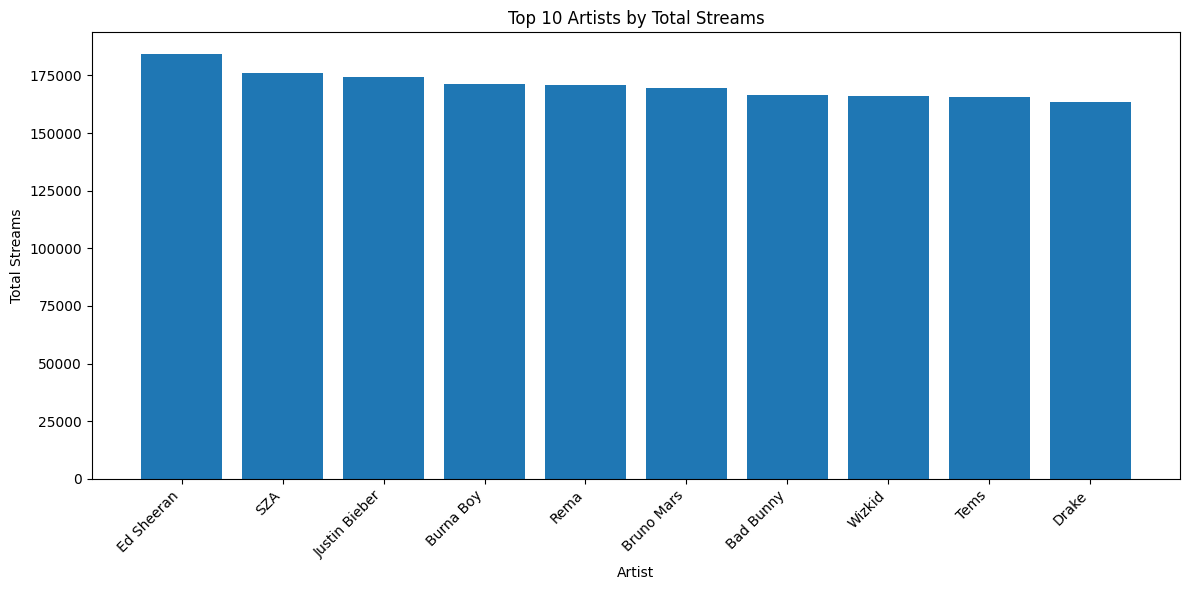

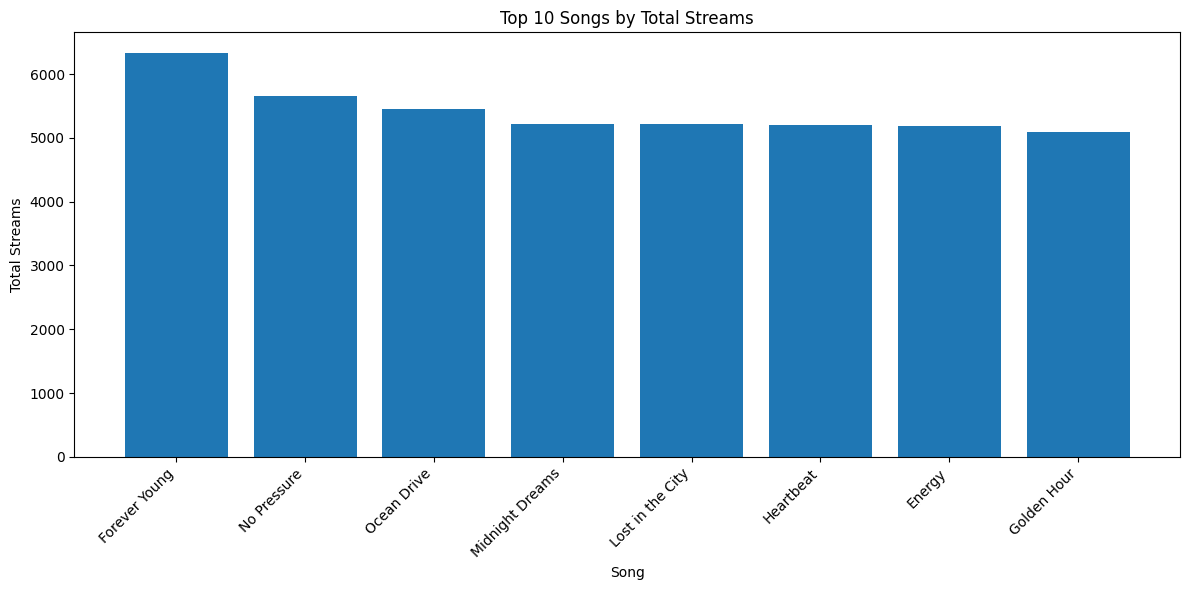

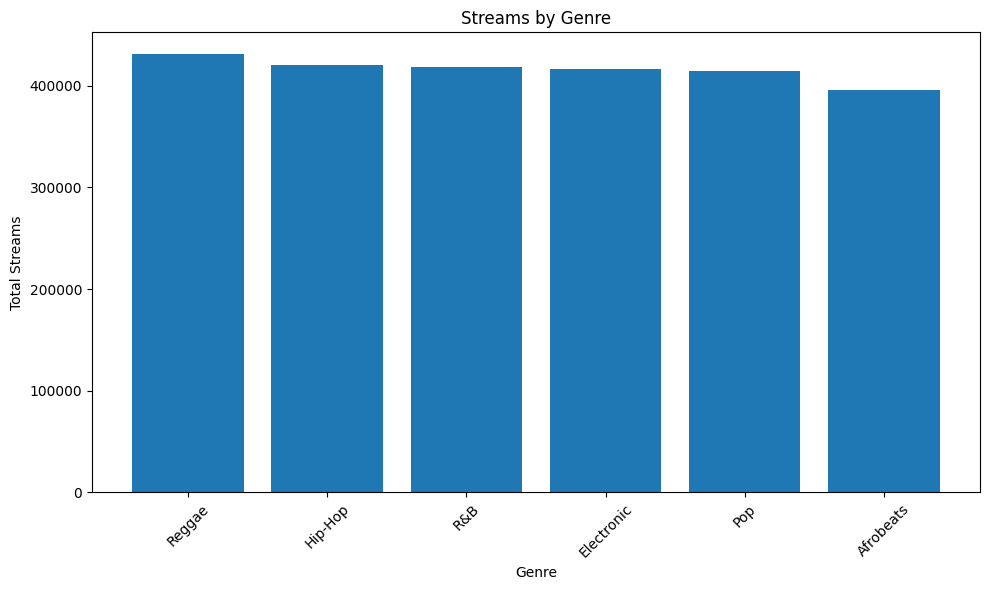

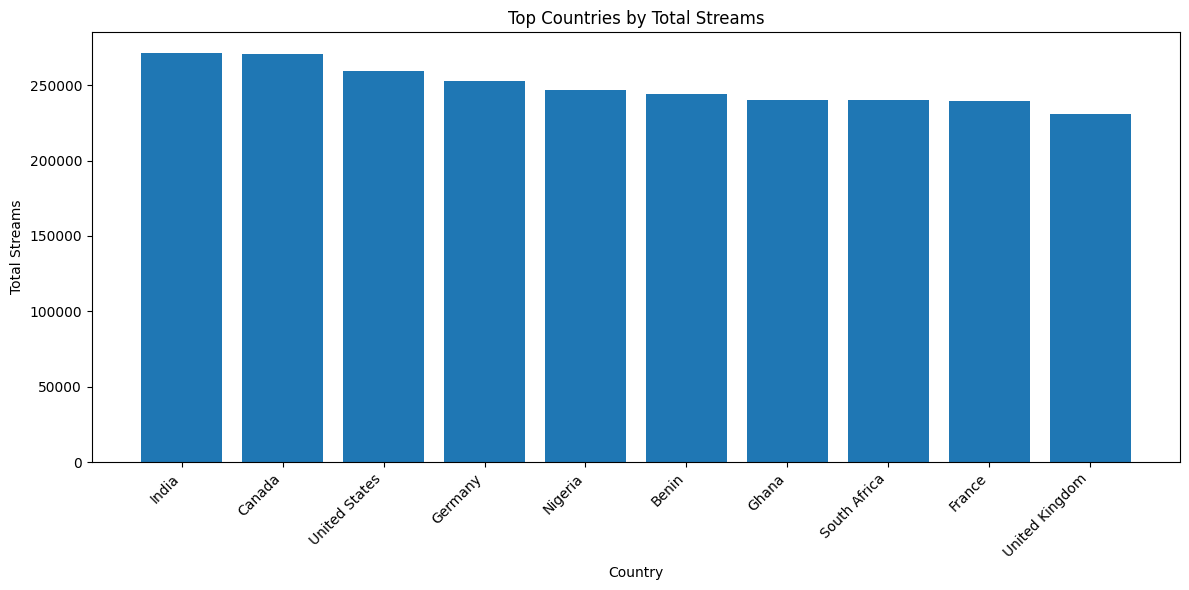

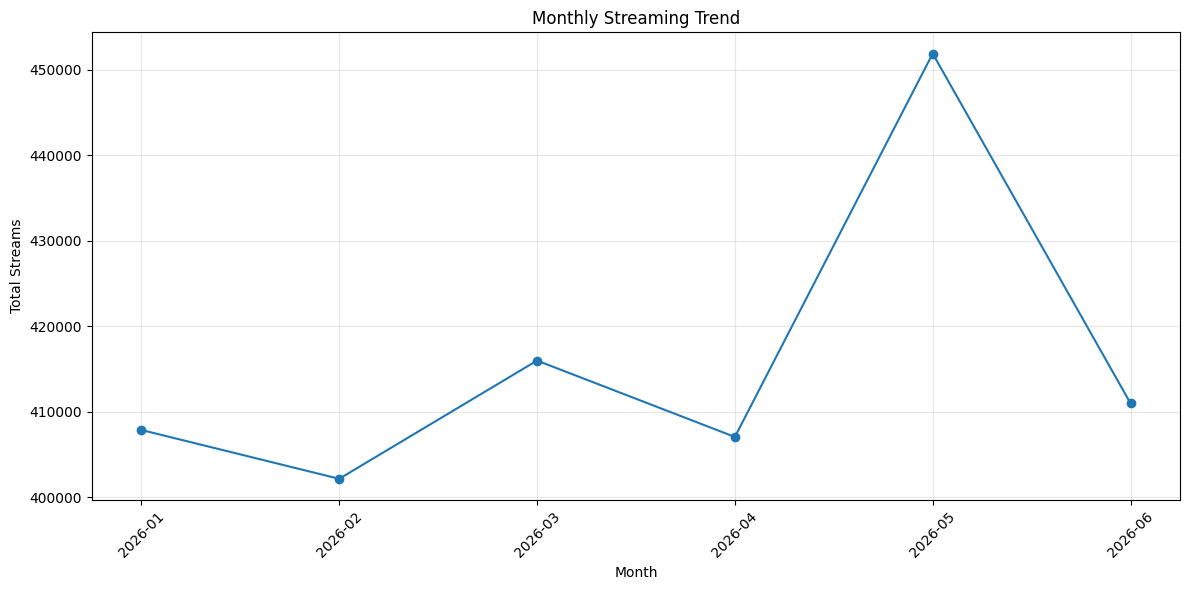

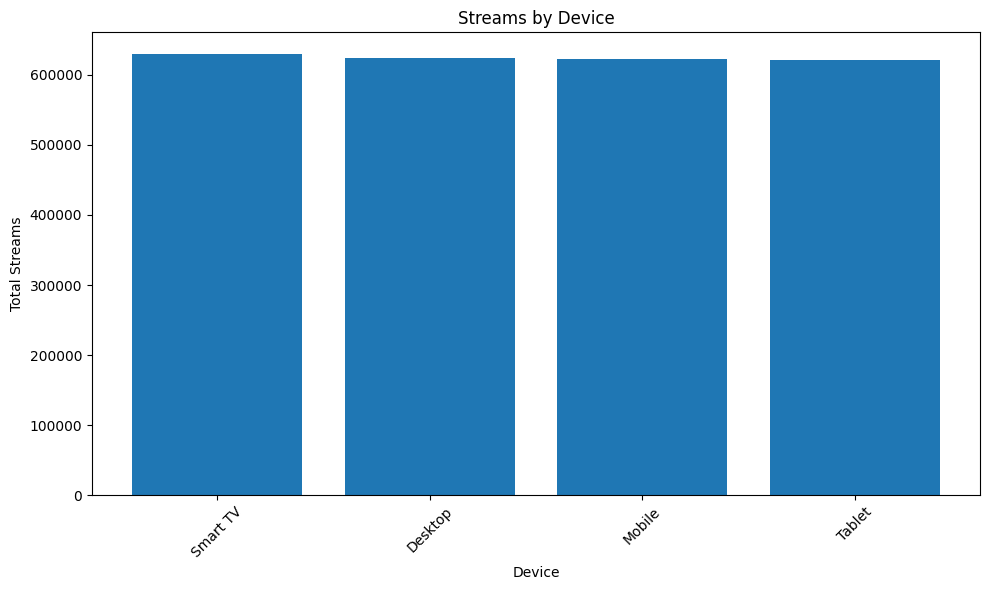


Clean dataset saved successfully.
Analysis files saved successfully.
SQLite database created successfully.

================ TOP ARTISTS FROM SQL ================
          artist  total_streams
0     Ed Sheeran         184445
1            SZA         175960
2  Justin Bieber         174405
3      Burna Boy         171053
4           Rema         170716
5     Bruno Mars         169471
6      Bad Bunny         166581
7         Wizkid         166200
8           Tems         165835
9          Drake         163316

================ DATA QUALITY CHECKS ================
Duplicate rows: 0
Missing values: 0
Negative streams: 0
Invalid user IDs: 0

       SPOTIFY-STYLE DATA PIPELINE COMPLETE
1. Data generation completed
2. Data cleaning completed
3. Feature engineering completed
4. Song analysis completed
5. Artist analysis completed
6. Genre analysis completed
7. Country analysis completed
8. City analysis completed
9. User analysis completed
10. Device analysis completed
11. Monthly analysis 

In [3]:
# ============================================================
# SPOTIFY-STYLE MUSIC DATA PIPELINE
# Data Engineering Project
# ============================================================

# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import sqlite3
from datetime import datetime, timedelta

print("Libraries imported successfully.")


# ============================================================
# 2. CREATE SAMPLE STREAMING DATA
# ============================================================

np.random.seed(42)

n_records = 5000

artists = [
    "Drake",
    "The Weeknd",
    "Taylor Swift",
    "Bad Bunny",
    "Burna Boy",
    "Wizkid",
    "Tems",
    "Rema",
    "Billie Eilish",
    "SZA",
    "Travis Scott",
    "Bruno Mars",
    "Ariana Grande",
    "Ed Sheeran",
    "Justin Bieber"
]

genres = [
    "Hip-Hop",
    "R&B",
    "Pop",
    "Afrobeats",
    "Reggae",
    "Electronic"
]

countries = [
    "India",
    "Nigeria",
    "Benin",
    "United States",
    "United Kingdom",
    "Canada",
    "France",
    "Ghana",
    "South Africa",
    "Germany"
]

cities = [
    "Delhi",
    "Mumbai",
    "Lagos",
    "Cotonou",
    "New York",
    "London",
    "Toronto",
    "Paris",
    "Accra",
    "Berlin"
]

songs = [
    "Midnight Dreams",
    "Golden Hour",
    "Love Again",
    "No Pressure",
    "Energy",
    "Lost in the City",
    "After Dark",
    "Summer Nights",
    "Ocean Drive",
    "Beautiful Things",
    "One More Time",
    "Paradise",
    "Heartbeat",
    "Memories",
    "Forever Young"
]

start_date = datetime(2026, 1, 1)

dates = [
    start_date + timedelta(days=np.random.randint(0, 180))
    for _ in range(n_records)
]

streaming_data = pd.DataFrame({
    "stream_id": range(1, n_records + 1),

    "user_id": np.random.randint(
        1000,
        2000,
        n_records
    ),

    "song": np.random.choice(
        songs,
        n_records
    ),

    "artist": np.random.choice(
        artists,
        n_records
    ),

    "genre": np.random.choice(
        genres,
        n_records
    ),

    "country_user": np.random.choice(
        countries,
        n_records
    ),

    "city": np.random.choice(
        cities,
        n_records
    ),

    "streams": np.random.randint(
        1,
        1000,
        n_records
    ),

    "duration_seconds": np.random.randint(
        120,
        360,
        n_records
    ),

    "date": dates,

    "device": np.random.choice(
        [
            "Mobile",
            "Desktop",
            "Tablet",
            "Smart TV"
        ],
        n_records
    )
})

print("\nDataset created successfully.")
print("Number of rows:", len(streaming_data))
print("Number of columns:", len(streaming_data.columns))


# ============================================================
# 3. DATA EXPLORATION
# ============================================================

print("\n================ DATASET PREVIEW ================")
print(streaming_data.head())

print("\n================ DATASET INFORMATION ================")
print(streaming_data.info())

print("\n================ MISSING VALUES ================")
print(streaming_data.isnull().sum())

print("\n================ STATISTICAL SUMMARY ================")
print(streaming_data.describe())


# ============================================================
# 4. DATA CLEANING
# ============================================================

# Remove duplicate rows
streaming_data = streaming_data.drop_duplicates()

# Remove rows with missing important values
streaming_data = streaming_data.dropna(
    subset=[
        "user_id",
        "song",
        "artist",
        "genre",
        "country_user",
        "streams"
    ]
)

# Convert date to datetime
streaming_data["date"] = pd.to_datetime(
    streaming_data["date"]
)

# Clean text columns
text_columns = [
    "song",
    "artist",
    "genre",
    "country_user",
    "city",
    "device"
]

for column in text_columns:
    streaming_data[column] = (
        streaming_data[column]
        .astype(str)
        .str.strip()
    )

# Make sure streams are numeric
streaming_data["streams"] = pd.to_numeric(
    streaming_data["streams"],
    errors="coerce"
)

# Remove invalid stream values
streaming_data = streaming_data[
    streaming_data["streams"] > 0
]

print("\nData cleaning completed.")
print("Rows after cleaning:", len(streaming_data))


# ============================================================
# 5. FEATURE ENGINEERING
# ============================================================

streaming_data["month"] = (
    streaming_data["date"]
    .dt.to_period("M")
    .astype(str)
)

streaming_data["year"] = (
    streaming_data["date"]
    .dt.year
)

streaming_data["day_of_week"] = (
    streaming_data["date"]
    .dt.day_name()
)

streaming_data["stream_minutes"] = (
    streaming_data["duration_seconds"] / 60
)

streaming_data["total_listening_minutes"] = (
    streaming_data["streams"]
    * streaming_data["stream_minutes"]
)

print("\nFeature engineering completed.")


# ============================================================
# 6. SONG ANALYSIS
# ============================================================

song_analysis = (
    streaming_data
    .groupby(
        [
            "song",
            "artist",
            "genre"
        ]
    )
    .agg(
        total_streams=(
            "streams",
            "sum"
        ),

        unique_users=(
            "user_id",
            "nunique"
        ),

        average_streams=(
            "streams",
            "mean"
        ),

        total_listening_minutes=(
            "total_listening_minutes",
            "sum"
        )
    )
    .reset_index()
    .sort_values(
        "total_streams",
        ascending=False
    )
)

print("\n================ TOP SONGS ================")
print(
    song_analysis.head(10)
)


# ============================================================
# 7. ARTIST ANALYSIS
# ============================================================

artist_analysis = (
    streaming_data
    .groupby("artist")
    .agg(
        total_streams=(
            "streams",
            "sum"
        ),

        unique_songs=(
            "song",
            "nunique"
        ),

        unique_users=(
            "user_id",
            "nunique"
        ),

        total_listening_minutes=(
            "total_listening_minutes",
            "sum"
        )
    )
    .reset_index()
    .sort_values(
        "total_streams",
        ascending=False
    )
)

print("\n================ TOP ARTISTS ================")
print(
    artist_analysis.head(10)
)


# ============================================================
# 8. GENRE ANALYSIS
# ============================================================

genre_analysis = (
    streaming_data
    .groupby("genre")
    .agg(
        total_streams=(
            "streams",
            "sum"
        ),

        unique_users=(
            "user_id",
            "nunique"
        ),

        unique_songs=(
            "song",
            "nunique"
        )
    )
    .reset_index()
    .sort_values(
        "total_streams",
        ascending=False
    )
)

print("\n================ GENRE ANALYSIS ================")
print(
    genre_analysis
)


# ============================================================
# 9. COUNTRY ANALYSIS
# ============================================================

country_analysis = (
    streaming_data
    .groupby("country_user")
    .agg(
        total_streams=(
            "streams",
            "sum"
        ),

        unique_users=(
            "user_id",
            "nunique"
        ),

        unique_songs=(
            "song",
            "nunique"
        ),

        average_streams=(
            "streams",
            "mean"
        )
    )
    .reset_index()
    .sort_values(
        "total_streams",
        ascending=False
    )
)

print("\n================ COUNTRY ANALYSIS ================")
print(
    country_analysis
)


# ============================================================
# 10. CITY ANALYSIS
# ============================================================

city_analysis = (
    streaming_data
    .groupby("city")
    .agg(
        total_streams=(
            "streams",
            "sum"
        ),

        unique_users=(
            "user_id",
            "nunique"
        )
    )
    .reset_index()
    .sort_values(
        "total_streams",
        ascending=False
    )
)

print("\n================ CITY ANALYSIS ================")
print(
    city_analysis
)


# ============================================================
# 11. MONTHLY STREAMING ANALYSIS
# ============================================================

monthly_analysis = (
    streaming_data
    .groupby("month")
    .agg(
        total_streams=(
            "streams",
            "sum"
        ),

        unique_users=(
            "user_id",
            "nunique"
        )
    )
    .reset_index()
)

print("\n================ MONTHLY ANALYSIS ================")
print(
    monthly_analysis
)


# ============================================================
# 12. DEVICE ANALYSIS
# ============================================================

device_analysis = (
    streaming_data
    .groupby("device")
    .agg(
        total_streams=(
            "streams",
            "sum"
        ),

        unique_users=(
            "user_id",
            "nunique"
        )
    )
    .reset_index()
    .sort_values(
        "total_streams",
        ascending=False
    )
)

print("\n================ DEVICE ANALYSIS ================")
print(
    device_analysis
)


# ============================================================
# 13. TOP USERS
# ============================================================

user_analysis = (
    streaming_data
    .groupby("user_id")
    .agg(
        total_streams=(
            "streams",
            "sum"
        ),

        songs_listened=(
            "song",
            "nunique"
        ),

        artists_listened=(
            "artist",
            "nunique"
        ),

        total_listening_minutes=(
            "total_listening_minutes",
            "sum"
        )
    )
    .reset_index()
    .sort_values(
        "total_streams",
        ascending=False
    )
)

print("\n================ TOP USERS ================")
print(
    user_analysis.head(10)
)


# ============================================================
# 14. KEY PERFORMANCE INDICATORS
# ============================================================

total_streams = streaming_data["streams"].sum()

total_users = streaming_data["user_id"].nunique()

total_songs = streaming_data["song"].nunique()

total_artists = streaming_data["artist"].nunique()

total_countries = streaming_data["country_user"].nunique()

total_genres = streaming_data["genre"].nunique()

total_listening_hours = (
    streaming_data["total_listening_minutes"].sum()
    / 60
)

average_streams_per_record = (
    streaming_data["streams"].mean()
)

print("\n================================================")
print("                    KPI SUMMARY")
print("================================================")

print(
    f"Total Streams: {total_streams:,}"
)

print(
    f"Total Users: {total_users:,}"
)

print(
    f"Total Songs: {total_songs:,}"
)

print(
    f"Total Artists: {total_artists:,}"
)

print(
    f"Total Countries: {total_countries:,}"
)

print(
    f"Total Genres: {total_genres:,}"
)

print(
    f"Total Listening Hours: "
    f"{total_listening_hours:,.2f}"
)

print(
    f"Average Streams per Record: "
    f"{average_streams_per_record:,.2f}"
)


# ============================================================
# 15. VISUALIZATION - TOP ARTISTS
# ============================================================

top_artists = artist_analysis.head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top_artists["artist"],
    top_artists["total_streams"]
)

plt.title(
    "Top 10 Artists by Total Streams"
)

plt.xlabel("Artist")

plt.ylabel("Total Streams")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()


# ============================================================
# 16. VISUALIZATION - TOP SONGS
# ============================================================

top_songs = song_analysis.head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top_songs["song"],
    top_songs["total_streams"]
)

plt.title(
    "Top 10 Songs by Total Streams"
)

plt.xlabel("Song")

plt.ylabel("Total Streams")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()


# ============================================================
# 17. VISUALIZATION - GENRES
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    genre_analysis["genre"],
    genre_analysis["total_streams"]
)

plt.title(
    "Streams by Genre"
)

plt.xlabel("Genre")

plt.ylabel("Total Streams")

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()


# ============================================================
# 18. VISUALIZATION - COUNTRIES
# ============================================================

top_countries = country_analysis.head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top_countries["country_user"],
    top_countries["total_streams"]
)

plt.title(
    "Top Countries by Total Streams"
)

plt.xlabel("Country")

plt.ylabel("Total Streams")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()


# ============================================================
# 19. VISUALIZATION - MONTHLY STREAMS
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_analysis["month"],
    monthly_analysis["total_streams"],
    marker="o"
)

plt.title(
    "Monthly Streaming Trend"
)

plt.xlabel("Month")

plt.ylabel("Total Streams")

plt.xticks(
    rotation=45
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 20. VISUALIZATION - DEVICES
# ============================================================

plt.figure(figsize=(10, 6))

plt.bar(
    device_analysis["device"],
    device_analysis["total_streams"]
)

plt.title(
    "Streams by Device"
)

plt.xlabel("Device")

plt.ylabel("Total Streams")

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()


# ============================================================
# 21. CREATE OUTPUT DIRECTORY
# ============================================================

os.makedirs(
    "outputs",
    exist_ok=True
)

os.makedirs(
    "data",
    exist_ok=True
)


# ============================================================
# 22. SAVE CLEAN DATA
# ============================================================

streaming_data.to_csv(
    "data/clean_streaming_data.csv",
    index=False
)

print(
    "\nClean dataset saved successfully."
)


# ============================================================
# 23. SAVE ANALYSIS RESULTS
# ============================================================

song_analysis.to_csv(
    "outputs/song_analysis.csv",
    index=False
)

artist_analysis.to_csv(
    "outputs/artist_analysis.csv",
    index=False
)

genre_analysis.to_csv(
    "outputs/genre_analysis.csv",
    index=False
)

country_analysis.to_csv(
    "outputs/country_analysis.csv",
    index=False
)

city_analysis.to_csv(
    "outputs/city_analysis.csv",
    index=False
)

monthly_analysis.to_csv(
    "outputs/monthly_analysis.csv",
    index=False
)

device_analysis.to_csv(
    "outputs/device_analysis.csv",
    index=False
)

user_analysis.to_csv(
    "outputs/user_analysis.csv",
    index=False
)

print(
    "Analysis files saved successfully."
)


# ============================================================
# 24. CREATE SQLITE DATABASE
# ============================================================

database_path = "streaming_database.db"

connection = sqlite3.connect(
    database_path
)

streaming_data.to_sql(
    "streaming_data",
    connection,
    if_exists="replace",
    index=False
)

song_analysis.to_sql(
    "song_analysis",
    connection,
    if_exists="replace",
    index=False
)

artist_analysis.to_sql(
    "artist_analysis",
    connection,
    if_exists="replace",
    index=False
)

genre_analysis.to_sql(
    "genre_analysis",
    connection,
    if_exists="replace",
    index=False
)

country_analysis.to_sql(
    "country_analysis",
    connection,
    if_exists="replace",
    index=False
)

connection.close()

print(
    "SQLite database created successfully."
)


# ============================================================
# 25. SQL ANALYSIS
# ============================================================

connection = sqlite3.connect(
    database_path
)

query = """
SELECT
    artist,
    SUM(streams) AS total_streams
FROM streaming_data
GROUP BY artist
ORDER BY total_streams DESC
LIMIT 10;
"""

top_artists_sql = pd.read_sql_query(
    query,
    connection
)

print(
    "\n================ TOP ARTISTS FROM SQL ================"
)

print(
    top_artists_sql
)

connection.close()


# ============================================================
# 26. DATA QUALITY CHECKS
# ============================================================

print(
    "\n================ DATA QUALITY CHECKS ================"
)

print(
    "Duplicate rows:",
    streaming_data.duplicated().sum()
)

print(
    "Missing values:",
    streaming_data.isnull().sum().sum()
)

print(
    "Negative streams:",
    (streaming_data["streams"] < 0).sum()
)

print(
    "Invalid user IDs:",
    streaming_data["user_id"].isnull().sum()
)


# ============================================================
# 27. FINAL PROJECT SUMMARY
# ============================================================

print("\n================================================")
print("       SPOTIFY-STYLE DATA PIPELINE COMPLETE")
print("================================================")

print(
    "1. Data generation completed"
)

print(
    "2. Data cleaning completed"
)

print(
    "3. Feature engineering completed"
)

print(
    "4. Song analysis completed"
)

print(
    "5. Artist analysis completed"
)

print(
    "6. Genre analysis completed"
)

print(
    "7. Country analysis completed"
)

print(
    "8. City analysis completed"
)

print(
    "9. User analysis completed"
)

print(
    "10. Device analysis completed"
)

print(
    "11. Monthly analysis completed"
)

print(
    "12. Data visualizations completed"
)

print(
    "13. CSV outputs created"
)

print(
    "14. SQLite database created"
)

print(
    "15. SQL analysis completed"
)

print(
    "16. Data quality checks completed"
)

print(
    "\nProject completed successfully!"
)

print(
    "Ready to upload to GitHub."
)